In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv(r"C:\Users\44752\OneDrive\Documents\Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### The dataset contains a mix of categorical and numerical features, with the majority being categorical.
#### The target variable is Churn, which is binary (Yes/No), confirming this is a classification problem.
#### Key numerical features include tenure, MonthlyCharges, and TotalCharges, which may be important predictors of churn

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### The TotalCharges column is stored as an object instead of a numeric type.
#### This is likely because the column contains some non-numeric values, such as empty strings or missing values.
#### This is a problem because we cannot perform numerical operations (such as calculating averages or using it in machine learning models) unless the column is converted to a numeric data type.

#### First, convert the column to numeric while handling invalid values.
#### Then, check for missing values created during conversion.
#### Finally, remove or handle those missing values appropriately.

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [10]:
df = df.dropna()

In [11]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### The TotalCharges column appears to be right-skewed because the mean is higher than the median (50th percentile).
#### This suggests that there are some large values pulling the average upwards, which is expected as long-term customers accumulate higher total charges.

**Tenure:**
#### The tenure column appears to be relatively evenly distributed, as the mean and median values are close to each other. This suggests that the data is not heavily skewed and there are no extreme outliers.

**MonthlyCharges:**
#### The MonthlyCharges column also shows a fairly balanced distribution, with the mean and median being close. This indicates that customer charges are spread reasonably evenly without strong skewness.

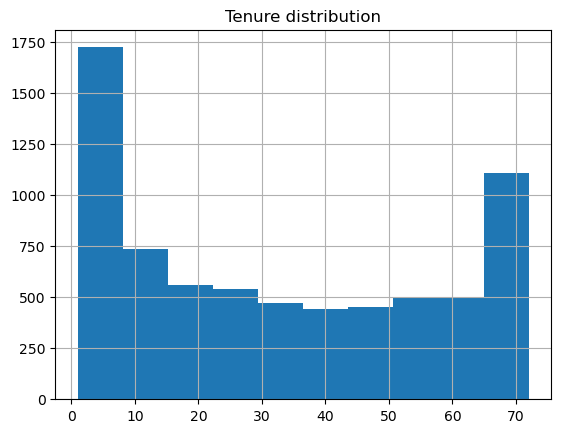

In [15]:
df['tenure'].hist()
plt.title('Tenure distribution')
plt.show()

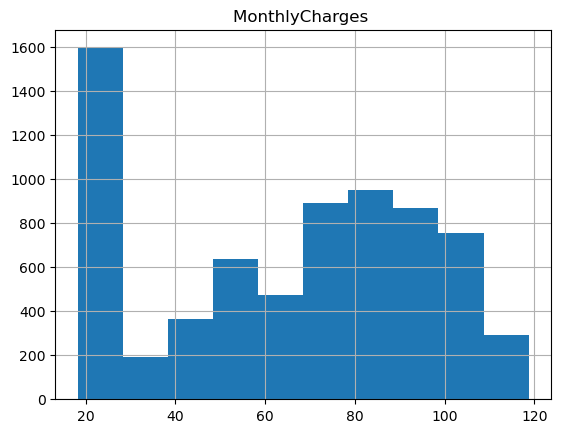

In [16]:
df['MonthlyCharges'].hist()
plt.title('MonthlyCharges ')
plt.show()

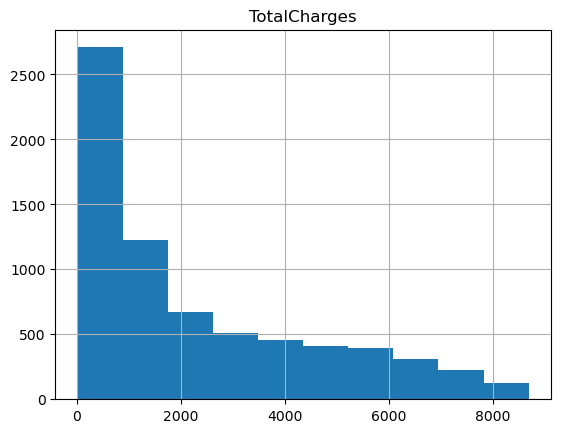

In [17]:
df['TotalCharges'].hist()
plt.title('TotalCharges')
plt.show()

#### Tenure Distribution:
#### The tenure distribution shows a non-uniform pattern with peaks at both low and high values. This suggests the presence of many new customers and many long-term customers, with fewer customers in the middle range.

#### MonthlyCharges Distribution:
#### The MonthlyCharges distribution appears to have two clusters, indicating that customers are grouped into lower-cost and higher-cost plans rather than being evenly distributed.

#### TotalCharges Distribution:
#### The TotalCharges distribution is right-skewed, as the mean is higher than the median. This is expected since customers who stay longer accumulate higher total charges over time.

# **Feature Importance Hypothesis**

#### I believe that tenure will be one of the most important features in predicting churn.
#### This is because customers with a longer tenure are more likely to be loyal and less likely to leave, while newer customers may be more likely to churn due to dissatisfaction, pricing concerns, or better offers from competitors.
#### Therefore, tenure is expected to have a strong relationship with churn behaviour.

#### MonthlyCharges may also significantly impact churn.
#### Customers with higher monthly charges may be more likely to leave, especially if competitors offer similar services at lower prices.
#### This effect may be particularly strong for newer customers who have not yet developed loyalty to the company.

In [21]:
df.groupby('Churn')['tenure'].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

In [22]:
df.groupby('Churn')['tenure'].median()

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

#### The analysis shows a clear relationship between tenure and churn.
#### Customers who did not churn have a significantly higher average tenure (~37 months) compared to those who churned (~17 months).
#### The median values further reinforce this, with non-churn customers having a median tenure of 38 months compared to 10 months for churned customers.

#### This suggests that customers with longer tenure are less likely to churn, while newer customers are at a higher risk of leaving.

#### However, this relationship should not be interpreted as causation. Other factors such as pricing, service quality, and competition may also influence churn behaviour.

In [24]:
df.groupby('Churn')['MonthlyCharges'].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [25]:
df.groupby('Churn')['MonthlyCharges'].median()

Churn
No     64.45
Yes    79.65
Name: MonthlyCharges, dtype: float64

## Churn vs MonthlyCharges Analysis

#### The analysis shows that customers who churn tend to have higher monthly charges compared to those who do not churn.
#### The average monthly charge for churned customers is approximately £74, compared to £61 for non-churned customers.
#### The median values also support this trend, indicating a consistent pattern.

#### This suggests that higher pricing may contribute to customer churn, as customers may seek more affordable alternatives from competitors.

#### However, the difference is less pronounced compared to tenure, indicating that while price plays a role, it may not be the strongest predictor of churn.
#### Additionally, churn is likely influenced by multiple factors, and pricing alone should not be considered the sole cause.

In [27]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


## Contract vs Churn Analysis

#### The analysis shows a strong relationship between contract type and churn.
#### Customers on month-to-month contracts have the highest churn rate (~42.7%), compared to those on one-year (~11.3%) and two-year contracts (~2.8%).

#### This indicates that customers with longer contracts are significantly less likely to churn.
#### A possible explanation is that longer contracts create commitment and reduce the likelihood of switching to competitors.

#### In contrast, customers on short-term (month-to-month) contracts have greater flexibility to leave, making them more prone to churn.

In [29]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index")

Churn,No,Yes
InternetService,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


## Internet Service vs Churn Analysis

#### The analysis shows that churn varies significantly by internet service type.
#### Customers using fiber optic internet have the highest churn rate, while those using DSL have lower churn rates.
#### Customers without internet service have the lowest churn.

#### This suggests that fiber optic customers may be more likely to leave, possibly due to higher costs or unmet expectations regarding service quality.
#### In contrast, DSL customers may experience more stable pricing or service, leading to lower churn.

## High-Risk Customer Profile

#### The most likely customer to churn is one who has a short tenure (new customer), is on a month-to-month contract, and pays higher monthly charges.
#### Additionally, customers using fiber optic internet services also show higher churn rates.

#### This suggests that new customers with flexible contracts and higher costs are more likely to leave, possibly due to dissatisfaction, lack of loyalty, or better alternatives offered by competitors.

## Categorical Data Handling

#### Machine learning models cannot directly process categorical data because they operate on numerical inputs.
#### Categorical variables such as "Yes/No" or service types (e.g., "DSL", "Fiber optic") must be converted into numerical representations so that the model can interpret patterns and relationships in the data.

#### Therefore, categorical features need to be encoded into numerical form before training a machine learning model.

#### Models perform mathematical operations (distance, weights, gradients)
#### So they NEED numbers

## Encoding Strategy

#### For this dataset, both label encoding and one-hot encoding will be used depending on the type of categorical variable.

#### Binary categorical variables (e.g., Yes/No) can be encoded using label encoding, as they only have two possible values.

#### For categorical variables with multiple categories and no natural order (e.g., contract type, internet service), one-hot encoding will be used to avoid introducing artificial relationships between categories.

## Target Variable Preparation

#### The target variable Churn is currently categorical (Yes/No), so it needs to be converted into a numeric format before training the model.
#### This will be done using label encoding, where:

#### Yes → 1
#### No → 0

In [36]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [38]:
df['Churn']=df['Churn'].map({'Yes': 1, 'No': 0})

In [39]:
df['Churn'].unique()

array([0, 1])

In [40]:
df_model = df.copy()

df_model = df_model.drop("customerID", axis=1)

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X = pd.get_dummies(X, drop_first=True)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [41]:
X = X.astype(int)
X.head()
X.shape

(7032, 30)

In [42]:
x.head(5)

NameError: name 'x' is not defined

In [ ]:
df.head(5)

In [ ]:
X.head(5)

## Data Preparation Summary

#### The original dataset (df) contains categorical variables in text format, which cannot be directly used in machine learning models.

#### The processed dataset (X) has been transformed using one-hot encoding, converting all categorical variables into numerical form.

#### This makes the dataset suitable for machine learning, as all features are now represented numerically.

In [53]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test= train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [55]:
X_train.shape, X_test.shape

((5625, 30), (1407, 30))

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

C:\Users\44752\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [58]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train, y_train)

C:\Users\44752\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


## Feature Scaling

#### Logistic Regression is sensitive to feature scale because it uses an optimization process to learn model weights. In this dataset, numerical features such as tenure, MonthlyCharges, and TotalCharges are on different scales, which can make convergence more difficult. Therefore, feature scaling is applied before training the model.

In [60]:
from sklearn.preprocessing import StandardScaler

In [62]:
scaler = StandardScaler()

In [63]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [68]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


#### After training the Logistic Regression model, it is necessary to evaluate its performance on unseen data.

#### The model is tested using the test dataset to assess how well it generalises to new customers.

#### Accuracy is used as an initial evaluation metric to measure the proportion of correct predictions made by the model.

In [71]:
y_pred = model.predict(X_test_scaled)

In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7882018479033405

#### The model achieved an accuracy of approximately 78%, meaning that it correctly predicts customer churn in around 78 out of 100 cases.

#### This indicates that the model has learned meaningful patterns from the data.
#### However, accuracy alone is not sufficient to fully evaluate the model, especially in problems like churn prediction where class imbalance may exist.

#### Therefore, additional evaluation metrics such as precision, recall, and confusion matrix are required to better understand model performance.


#### A confusion matrix in machine learning is a simple table used to check how well a classification model is performing.

In [76]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[915, 118],
       [180, 194]])

|                | Predicted No | Predicted Yes |
| -------------- | ------------ | ------------- |
| **Actual No**  | 915 (TN)     | 118 (FP)      |
| **Actual Yes** | 180 (FN)     | 194 (TP)      |


#### The confusion matrix shows that the model correctly predicts a large number of non-churn customers (915 true negatives).

#### However, the model struggles more with predicting churn cases. While it correctly identifies 194 churn cases (true positives), it incorrectly classifies 180 churning customers as non-churn (false negatives).

#### This is a critical issue because false negatives represent customers who leave the company without being identified, resulting in potential revenue loss.

#### Additionally, the model produces 118 false positives, meaning some customers are incorrectly predicted to churn. While this may lead to unnecessary retention efforts, it is generally less harmful than missing actual churn cases.

#### Overall, the model performs reasonably well but requires improvement in detecting churn (positive class), which is the more important outcome from a business perspective.

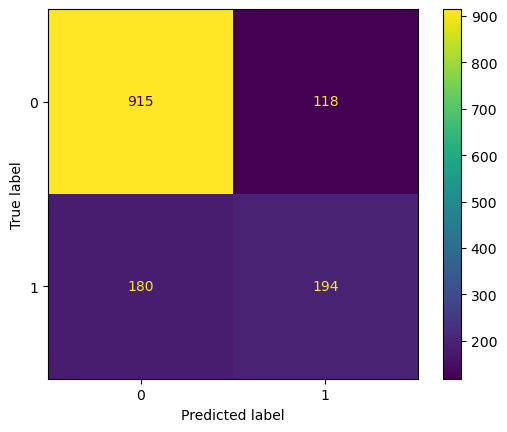

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

In [83]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Class 0 (No churn)
#### Precision = 0.84
#### 👉 Out of all predicted “No churn”, 84% were correct
#### Recall = 0.89
#### 👉 Out of all actual “No churn”, model caught 89%

#### This is VERY GOOD

## Class 1 (Churn) — IMPORTANT
#### Precision = 0.62
#### 👉 Out of all predicted churn, only 62% were actually churn
#### Recall = 0.52 🚨
#### 👉 Out of all actual churn customers, model only caught 52%

#### The model performs well in predicting non-churn customers, achieving high precision (0.84) and recall (0.89).

#### However, performance is significantly weaker for predicting churn. While the precision for churn is 0.62, the recall is only 0.52, meaning the model correctly identifies just over half of the customers who actually churn.

#### This is a critical limitation because recall is particularly important in churn prediction. A low recall indicates that many customers who are likely to leave are not being identified by the model.

#### From a business perspective, this can result in missed opportunities to retain customers, leading to potential revenue loss.

#### Therefore, improving recall for the churn class should be a priority, even if it slightly reduces overall accuracy.

#### Lowering the decision threshold makes the model more sensitive to predicting churn. This increases recall because more actual churn customers are correctly identified. However, it decreases precision because more non-churn customers may be incorrectly classified as churn.

#### Lower threshold =

#### ✅ Catch more customers who might leave
#### ❌ But also target some who wouldn’t leave

#### In churn prediction, it is often better to prioritise recall over precision, as missing a churned customer is more costly than incorrectly targeting a non-churn customer.

#### lowering threshold from probability customer churn >0.5 to > 0.3

In [91]:
y_prob = model.predict_proba(X_test_scaled)[:,1]
y_pred_new = (y_prob >= 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1033
           1       0.53      0.76      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.77      1407



#### After lowering the classification threshold from 0.5 to 0.3, the model became more sensitive in predicting churn.

#### The recall for churn (class 1) improved significantly from 0.52 to 0.76, meaning the model now correctly identifies a much larger proportion of customers who are likely to churn.

#### However, this improvement comes at the cost of precision, which decreased from 0.62 to 0.53, indicating an increase in false positives where non-churn customers are incorrectly predicted as churn.

#### Additionally, overall accuracy decreased slightly from 78% to 75%, reflecting the trade-off between recall and precision.

#### From a business perspective, this trade-off may be acceptable, as identifying more potential churn customers is often more valuable than maintaining higher overall accuracy.

#### I would choose the model with a threshold of 0.3 because it achieves significantly higher recall for churn.

#### In this business problem, recall is more important than precision, as failing to identify customers who are likely to churn can result in lost revenue.

#### Although lowering the threshold increases false positives (predicting churn when the customer would not leave), this is generally less costly than missing actual churn cases.

#### Therefore, prioritising recall allows the business to proactively target more at-risk customers, improving retention strategies.